In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# S&P500

In [23]:
ticker = "^GSPC"
data = yf.download(ticker, start="2023-01-01", end="2026-09-30",auto_adjust=True, progress=False
                  ).droplevel(['Ticker'], axis=1).reset_index(drop=False).rename_axis(ticker)

In [24]:
data['Return'] = data.Close.pct_change()
data['Target'] = data['Return'].shift(-1)
data['Direction'] = (data['Target'] > 0).astype(int)
data["MA5"] = data["Close"].rolling(5).mean()
data["MA20"] = data["Close"].rolling(20).mean()
data["Volatility_5"] = data["Return"].rolling(5).std()
data = data.dropna(axis=0)
data.tail(3)

Price,Date,Close,High,Low,Open,Volume,Return,Target,Direction,MA5,MA20,Volatility_5
^GSPC,,,,,,,,,,,,
934,2026-09-24,7704.129883,7719.009766,7662.569824,7666.990234,5316390000,-0.000247,0.005099,1,7718.000000,7671.855518,0.008173
935,2026-09-25,7743.410156,7752.069824,7693.080078,7709.859863,4499180000,0.005099,-0.007712,0,7736.582031,7672.476514,0.008306
936,2026-09-28,7683.689941,7724.149902,7666.600098,7721.700195,5129710000,-0.007712,-0.001672,0,7720.379980,7671.073022,0.005496


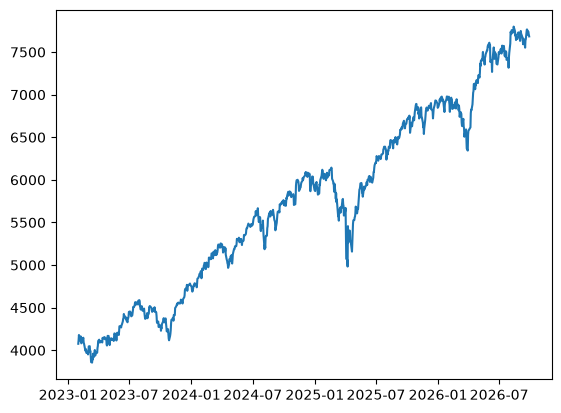

In [25]:
plt.plot(data.Date,data.Close)
plt.show()

## Regression

In [26]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0119
MAPE    : 5.867


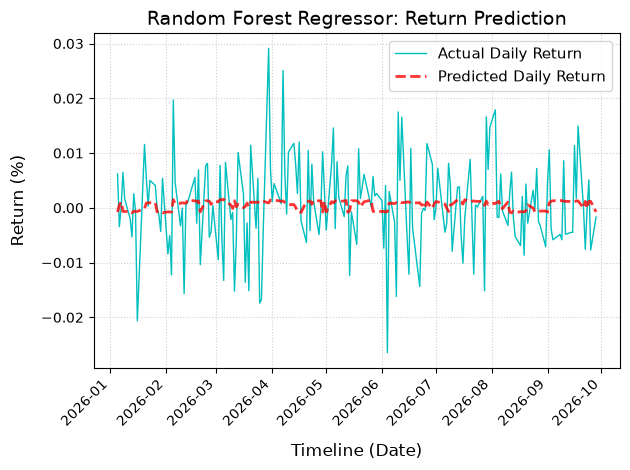

In [27]:
plt.plot(data['Date'][split_idx:], data['Target'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [28]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

result_fig = [[],[],[]]
rmse_list = [[],[],[]]
mae_list = [[],[],[]]
r2_score_list = [[],[],[]]


for n in [1,2,3]:
    for d in range(3, 11, 1):
        reg_model = RandomForestRegressor(n_estimators=n*100, max_depth=d, random_state=42, n_jobs=-1, min_samples_leaf=30)
        reg_model.fit(X_train_r, y_train_r)

        y_pred_r = reg_model.predict(X_test_r)
        result_fig[n-1].append(y_pred_r)
        rmse_reg = root_mean_squared_error(y_test_r, y_pred_r)
        mae_reg = mean_absolute_error(y_test_r, y_pred_r)
        r2_reg = r2_score(y_test_r, y_pred_r)
        rmse_list[n-1].append(rmse_reg)
        mae_list[n-1].append(mae_reg)
        r2_score_list[n-1].append(r2_reg)
        print(f"n_estimators: {n*100}, max_depth: {d}")
        print(f"RMSE    : {rmse_reg:.4f}")
        print(f"MAE     : {mae_reg:.4f}")
        print(f"R2 Score: {r2_reg:.4f}")
        print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

n_estimators: 100, max_depth: 3
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0137
MAPE    : 4.978
n_estimators: 100, max_depth: 4
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0119
MAPE    : 5.867
n_estimators: 100, max_depth: 5
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0105
MAPE    : 6.483
n_estimators: 100, max_depth: 6
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0092
MAPE    : 6.856
n_estimators: 100, max_depth: 7
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0083
MAPE    : 6.699
n_estimators: 100, max_depth: 8
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0083
MAPE    : 6.678
n_estimators: 100, max_depth: 9
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0083
MAPE    : 6.678
n_estimators: 100, max_depth: 10
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0083
MAPE    : 6.678
n_estimators: 200, max_depth: 3
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0135
MAPE    : 4.629
n_estimators: 200, max_depth: 4
RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0123
MAPE    : 5.387
n_estimat

In [29]:
r2_array = np.array(r2_score_list)
best_n, best_d = np.where(r2_array == r2_array.max())
best_n = (best_n+1)*100
best_d = best_d+3
print(f"Best n_estimators and max_depth: {best_n}, {best_d}")

Best n_estimators and max_depth: [100], [3]


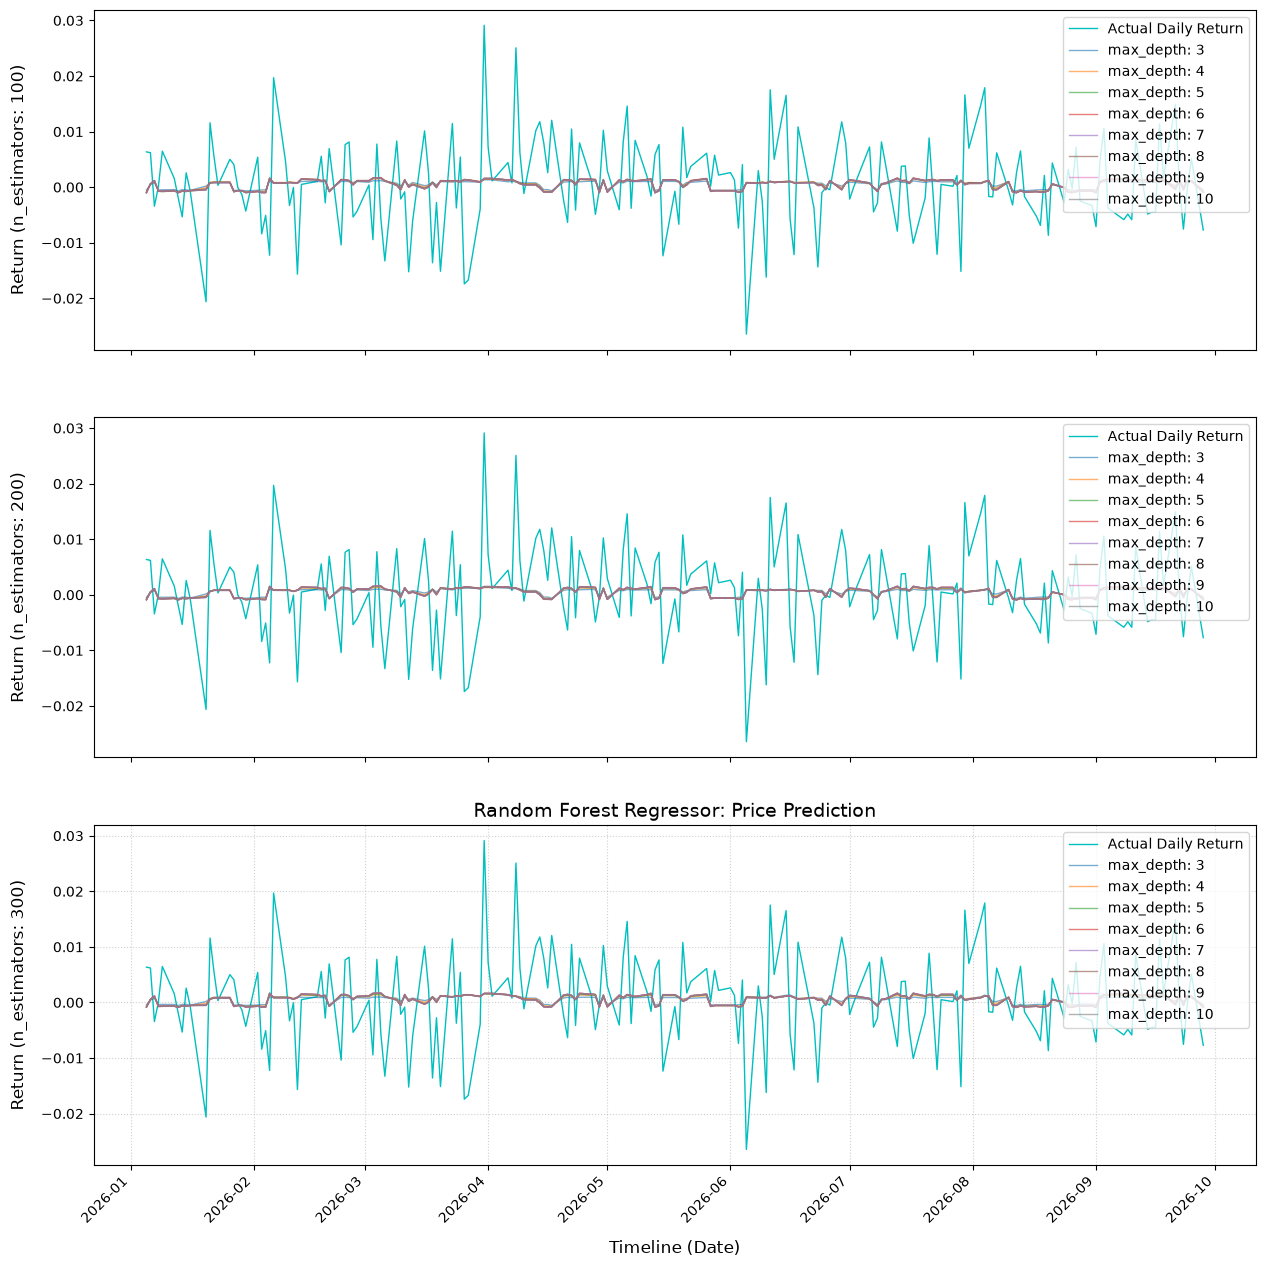

In [30]:
fig, axs = plt.subplots(3,1, figsize=(15,15), sharex=True)
for i in range(3):
    axs[i].plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
    for j in range(3,11,1):
        axs[i].plot(data['Date'][split_idx:], result_fig[i][j-3], label=f"max_depth: {j}", linewidth=1, alpha=0.6)
    axs[i].set_ylabel(f"Return (n_estimators: {(i+1)*100})", fontsize=12, labelpad=10)
    axs[i].legend()
    plt.grid(True, linestyle=":", alpha=0.6)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.show()

In [31]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0083
MAE     : 0.0064
R2 Score: 0.0137
MAPE    : 4.978


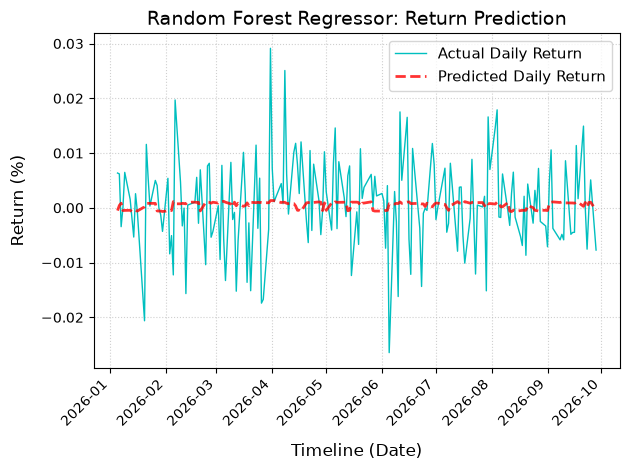

In [32]:
plt.plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [33]:
pred_data = pd.DataFrame(data['Date'][split_idx:].copy()) 
pred_data['Pre_Return'] = y_pred_r 
pred_data['Close'] = data['Close'].copy()
a = [data['Close'].iloc[pred_data.index[0]-data.index[0]]]
for i in range(len(pred_data['Pre_Return'])):
    a.append(a[i-1]*(1+pred_data['Pre_Return'].iloc[i-1]))
pred_data['Pre_Close'] = a[:-1]
pred_data.tail()

,Date,Pre_Return,Close,Pre_Close
^GSPC,,,,
932,2026-09-22,0.000983,7764.640137,7219.608815
933,2026-09-23,0.000187,7706.029785,7204.328296
934,2026-09-24,0.000983,7704.129883,7226.704145
935,2026-09-25,0.001023,7743.410156,7205.677335
936,2026-09-28,-0.000466,7683.689941,7233.806448


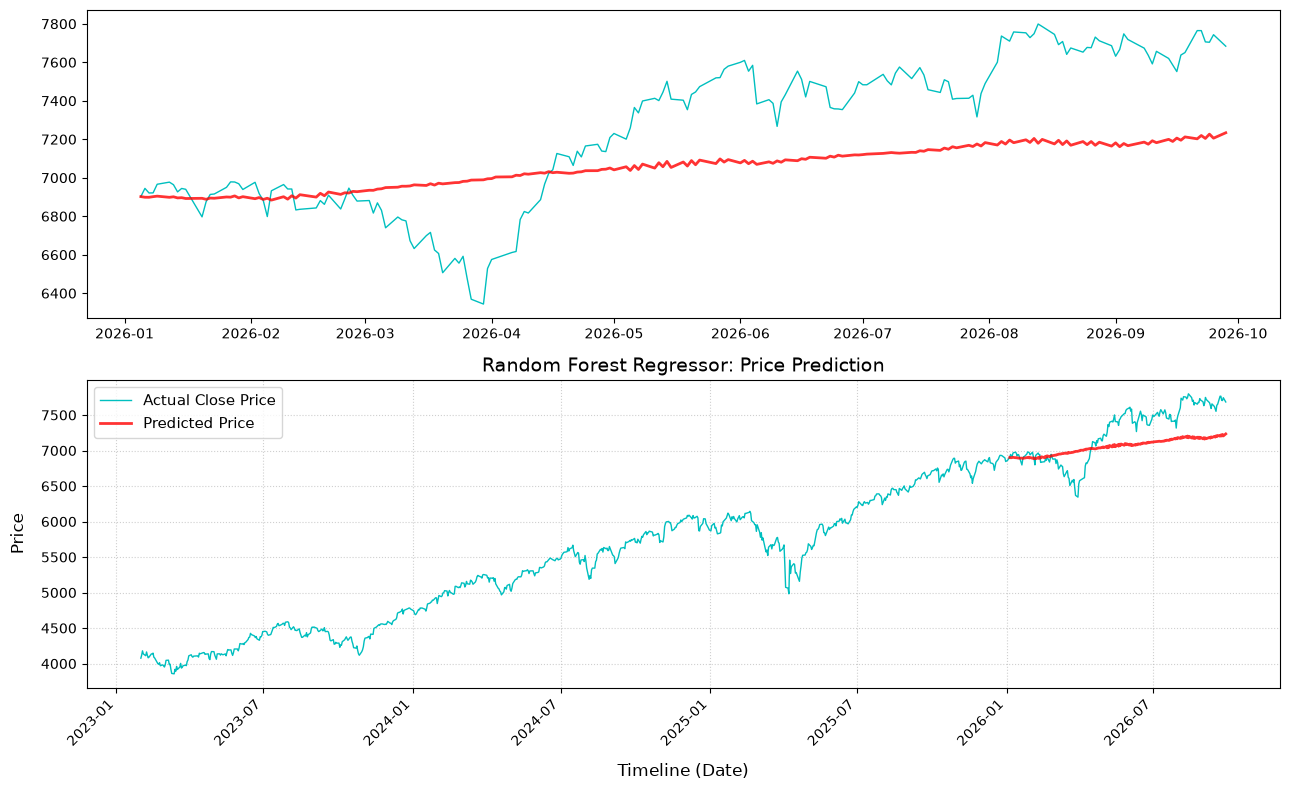

In [34]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(13,8))
ax1.plot(data['Date'][split_idx:], data['Close'][split_idx:], 'c-', label='Actual Close Price', linewidth=1)
ax1.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)
ax2.plot(data['Date'], data['Close'], 'c-', label='Actual Close Price', linewidth=1)
ax2.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Price", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [35]:
print(f"RMSE    : {root_mean_squared_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAE     : {mean_absolute_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"R2 Score: {r2_score(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4}")

RMSE    : 345.5056
MAE     : 293.0731
R2 Score: 0.1670
MAPE    : 0.03983


## Classification

In [36]:
y_cl = data["Direction"]
X_cl = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data) * 0.8)
X_train_c, X_test_c = X_cl.iloc[:split_idx], X_cl.iloc[split_idx:]
y_train_c, y_test_c = y_cl.iloc[:split_idx], y_cl.iloc[split_idx:]

reg_model = RandomForestClassifier(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1)
reg_model.fit(X_train_c, y_train_c)
y_pred_c = reg_model.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.41      0.08      0.13        90
           1       0.50      0.89      0.64        94

    accuracy                           0.49       184
   macro avg       0.46      0.49      0.39       184
weighted avg       0.46      0.49      0.39       184



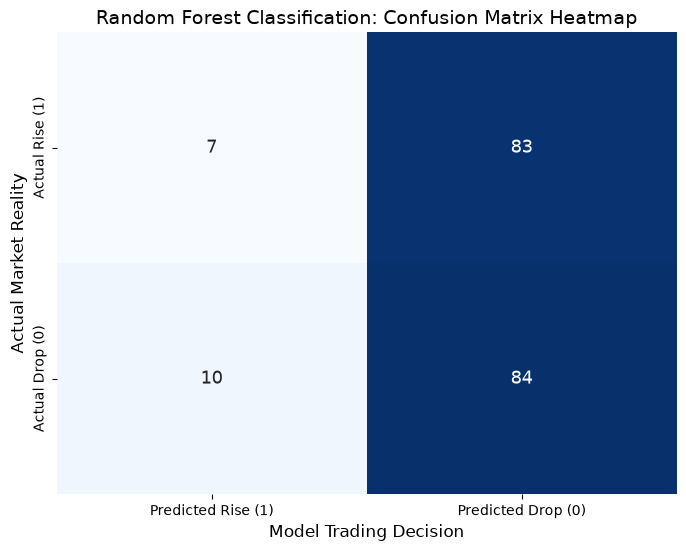

In [37]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Rise (1)", "Predicted Drop (0)"],
    yticklabels=["Actual Rise (1)", "Actual Drop (0)"],
    annot_kws={"size": 13},
    cbar=False
)

plt.title("Random Forest Classification: Confusion Matrix Heatmap", fontsize=14)
plt.ylabel("Actual Market Reality", fontsize=12)
plt.xlabel("Model Trading Decision", fontsize=12)
plt.show()

# HSI

In [38]:
ticker = "^HSI"
data = yf.download(ticker, start="2023-01-01", end="2026-09-30",auto_adjust=True, progress=False
                  ).droplevel(['Ticker'], axis=1).reset_index(drop=False).rename_axis(ticker)

In [39]:
data['Return'] = data.Close.pct_change()
data['Target'] = data['Return'].shift(-1)
data['Direction'] = (data['Target'] > 0).astype(int)
data["MA5"] = data["Close"].rolling(5).mean()
data["MA20"] = data["Close"].rolling(20).mean()
data["Volatility_5"] = data["Return"].rolling(5).std()
data = data.dropna(axis=0)
data.tail(3)

Price,Date,Close,High,Low,Open,Volume,Return,Target,Direction,MA5,MA20,Volatility_5
^HSI,,,,,,,,,,,,
914,2026-09-24,24761.130859,24791.199219,24648.289062,24649.449219,1927300000,-0.002939,-0.010139,0,24895.298047,25090.083008,0.008370
915,2026-09-25,24510.089844,24537.140625,24275.560547,24523.500000,1343800000,-0.010139,0.005403,1,24847.160156,25036.348047,0.009187
916,2026-09-28,24642.509766,24767.220703,24554.580078,24554.580078,2328900000,0.005403,-0.004827,0,24767.119922,24990.124023,0.006981


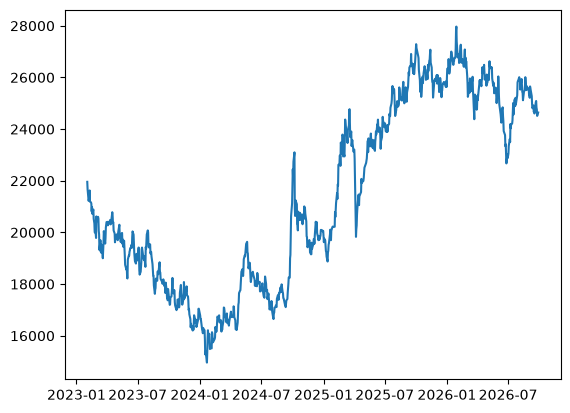

In [40]:
plt.plot(data.Date,data.Close)
plt.show()

## Regression

In [41]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0118
MAE     : 0.0096
R2 Score: -0.0196
MAPE    : 1.394


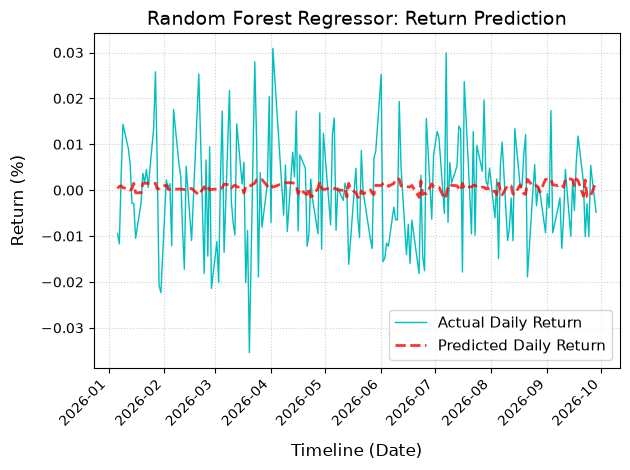

In [42]:
plt.plot(data['Date'][split_idx:], data['Target'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [43]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

result_fig = [[],[],[]]
rmse_list = [[],[],[]]
mae_list = [[],[],[]]
r2_score_list = [[],[],[]]


for n in [1,2,3]:
    for d in range(3, 11, 1):
        reg_model = RandomForestRegressor(n_estimators=n*100, max_depth=d, random_state=42, n_jobs=-1, min_samples_leaf=30)
        reg_model.fit(X_train_r, y_train_r)

        y_pred_r = reg_model.predict(X_test_r)
        result_fig[n-1].append(y_pred_r)
        rmse_reg = root_mean_squared_error(y_test_r, y_pred_r)
        mae_reg = mean_absolute_error(y_test_r, y_pred_r)
        r2_reg = r2_score(y_test_r, y_pred_r)
        rmse_list[n-1].append(rmse_reg)
        mae_list[n-1].append(mae_reg)
        r2_score_list[n-1].append(r2_reg)
        print(f"n_estimators: {n*100}, max_depth: {d}")
        print(f"RMSE    : {rmse_reg:.4f}")
        print(f"MAE     : {mae_reg:.4f}")
        print(f"R2 Score: {r2_reg:.4f}")
        print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

n_estimators: 100, max_depth: 3
RMSE    : 0.0118
MAE     : 0.0095
R2 Score: -0.0091
MAPE    : 1.325
n_estimators: 100, max_depth: 4
RMSE    : 0.0118
MAE     : 0.0096
R2 Score: -0.0196
MAPE    : 1.394
n_estimators: 100, max_depth: 5
RMSE    : 0.0119
MAE     : 0.0096
R2 Score: -0.0243
MAPE    : 1.459
n_estimators: 100, max_depth: 6
RMSE    : 0.0119
MAE     : 0.0096
R2 Score: -0.0309
MAPE    : 1.493
n_estimators: 100, max_depth: 7
RMSE    : 0.0119
MAE     : 0.0096
R2 Score: -0.0347
MAPE    : 1.569
n_estimators: 100, max_depth: 8
RMSE    : 0.0119
MAE     : 0.0096
R2 Score: -0.0345
MAPE    : 1.576
n_estimators: 100, max_depth: 9
RMSE    : 0.0119
MAE     : 0.0096
R2 Score: -0.0356
MAPE    : 1.566
n_estimators: 100, max_depth: 10
RMSE    : 0.0119
MAE     : 0.0096
R2 Score: -0.0359
MAPE    : 1.569
n_estimators: 200, max_depth: 3
RMSE    : 0.0118
MAE     : 0.0095
R2 Score: -0.0130
MAPE    : 1.395
n_estimators: 200, max_depth: 4
RMSE    : 0.0119
MAE     : 0.0096
R2 Score: -0.0226
MAPE    : 1.453

In [44]:
r2_array = np.array(r2_score_list)
best_n, best_d = np.where(r2_array == r2_array.max())
best_n = (best_n+1)*100
best_d = best_d+3
print(f"Best n_estimators and max_depth: {best_n}, {best_d}")

Best n_estimators and max_depth: [100], [3]


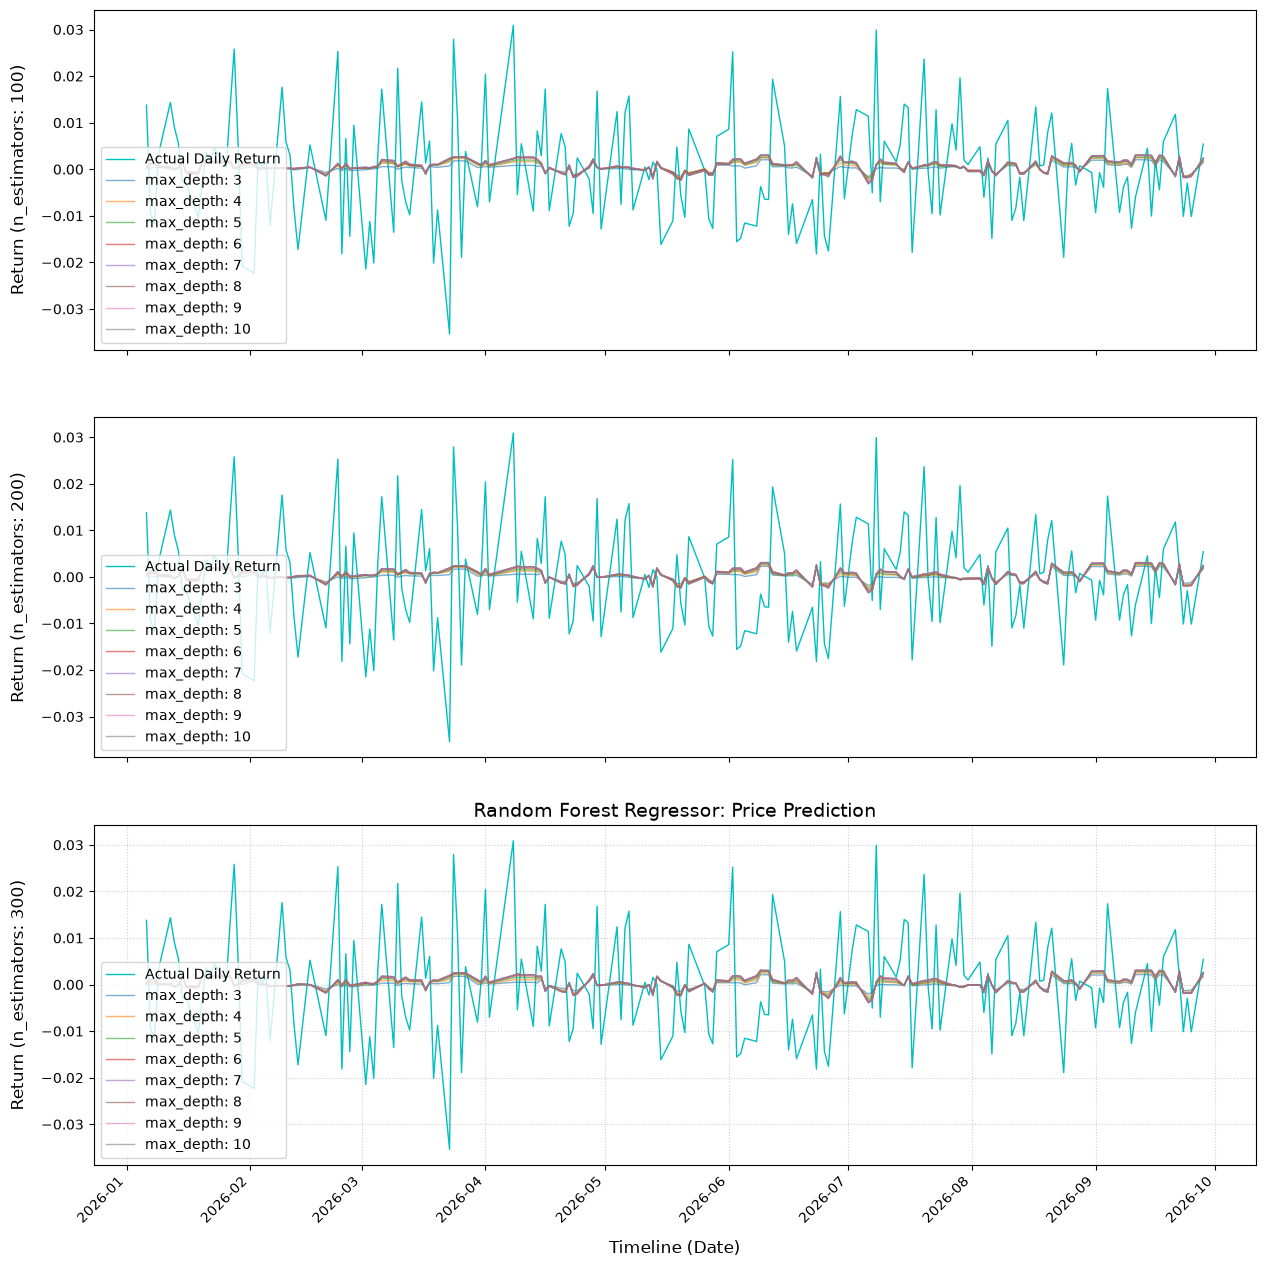

In [45]:
fig, axs = plt.subplots(3,1, figsize=(15,15), sharex=True)
for i in range(3):
    axs[i].plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
    for j in range(3,11,1):
        axs[i].plot(data['Date'][split_idx:], result_fig[i][j-3], label=f"max_depth: {j}", linewidth=1, alpha=0.6)
    axs[i].set_ylabel(f"Return (n_estimators: {(i+1)*100})", fontsize=12, labelpad=10)
    axs[i].legend()
    plt.grid(True, linestyle=":", alpha=0.6)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.show()

In [46]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0118
MAE     : 0.0095
R2 Score: -0.0091
MAPE    : 1.325


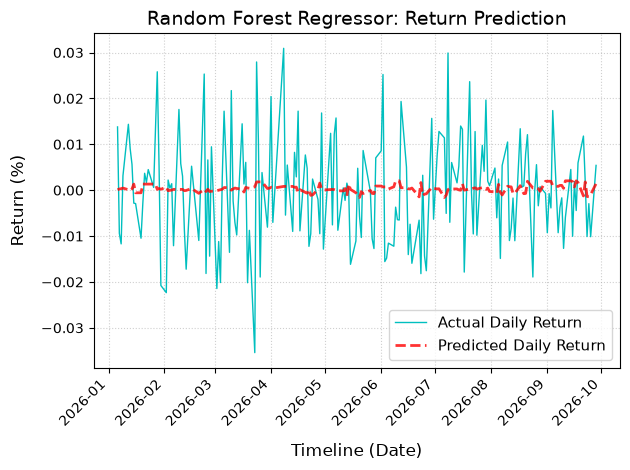

In [47]:
plt.plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [48]:
pred_data = pd.DataFrame(data['Date'][split_idx:].copy()) 
pred_data['Pre_Return'] = y_pred_r 
pred_data['Close'] = data['Close'].copy()
a = [data['Close'].iloc[pred_data.index[0]-data.index[0]]]
for i in range(len(pred_data['Pre_Return'])):
    a.append(a[i-1]*(1+pred_data['Pre_Return'].iloc[i-1]))
pred_data['Pre_Close'] = a[:-1]
pred_data.tail()

,Date,Pre_Return,Close,Pre_Close
^HSI,,,,
912,2026-09-22,0.001820,25087.750000,27759.011663
913,2026-09-23,-0.001373,24834.119141,27361.749522
914,2026-09-24,-0.001423,24761.130859,27809.539961
915,2026-09-25,-0.000953,24510.089844,27324.191446
916,2026-09-28,0.001419,24642.509766,27769.969614


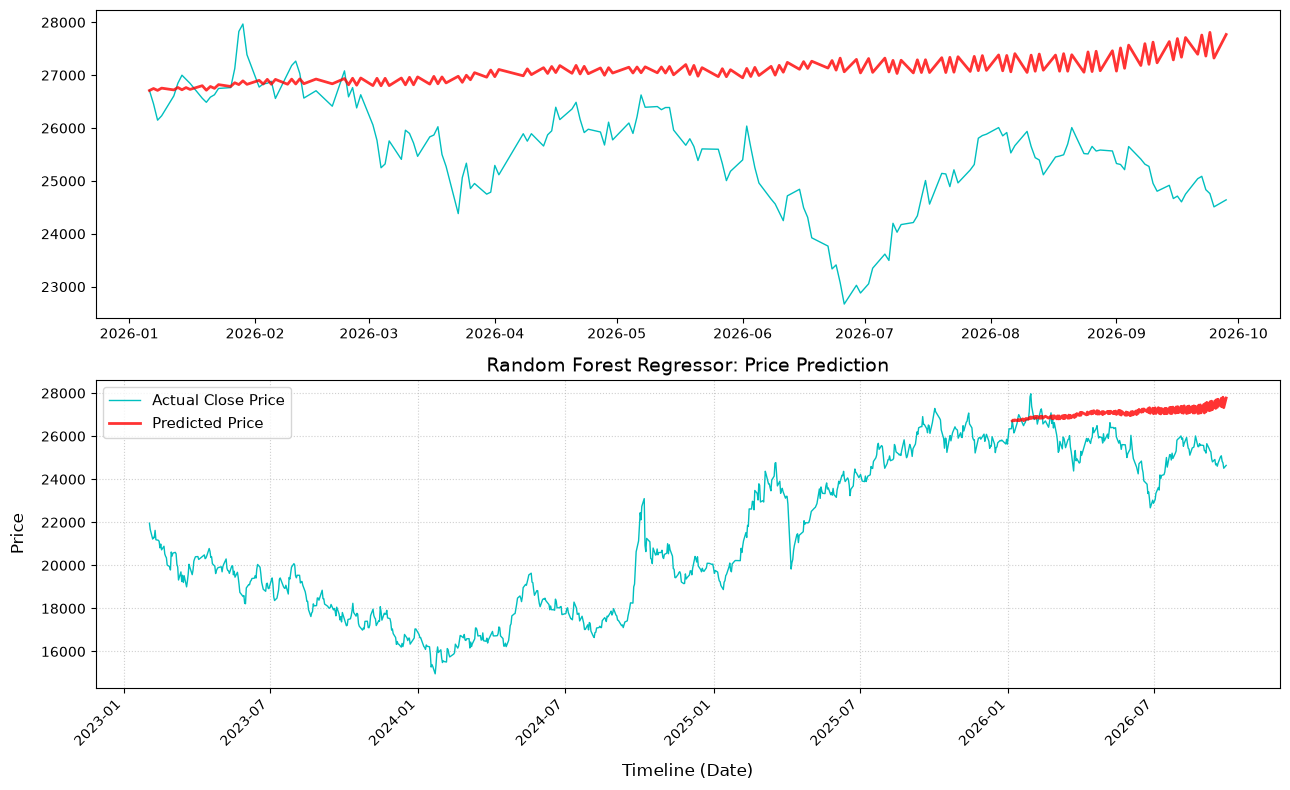

In [49]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(13,8))
ax1.plot(data['Date'][split_idx:], data['Close'][split_idx:], 'c-', label='Actual Close Price', linewidth=1)
ax1.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)
ax2.plot(data['Date'], data['Close'], 'c-', label='Actual Close Price', linewidth=1)
ax2.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Price", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [50]:
print(f"RMSE    : {root_mean_squared_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAE     : {mean_absolute_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"R2 Score: {r2_score(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4}")

RMSE    : 1900.8267
MAE     : 1596.1145
R2 Score: -2.7666
MAPE    : 0.06409


## Classification

In [51]:
y_cl = data["Direction"]
X_cl = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data) * 0.8)
X_train_c, X_test_c = X_cl.iloc[:split_idx], X_cl.iloc[split_idx:]
y_train_c, y_test_c = y_cl.iloc[:split_idx], y_cl.iloc[split_idx:]

reg_model = RandomForestClassifier(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1)
reg_model.fit(X_train_c, y_train_c)
y_pred_c = reg_model.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.42      0.17      0.24        90
           1       0.48      0.77      0.59        90

    accuracy                           0.47       180
   macro avg       0.45      0.47      0.41       180
weighted avg       0.45      0.47      0.41       180



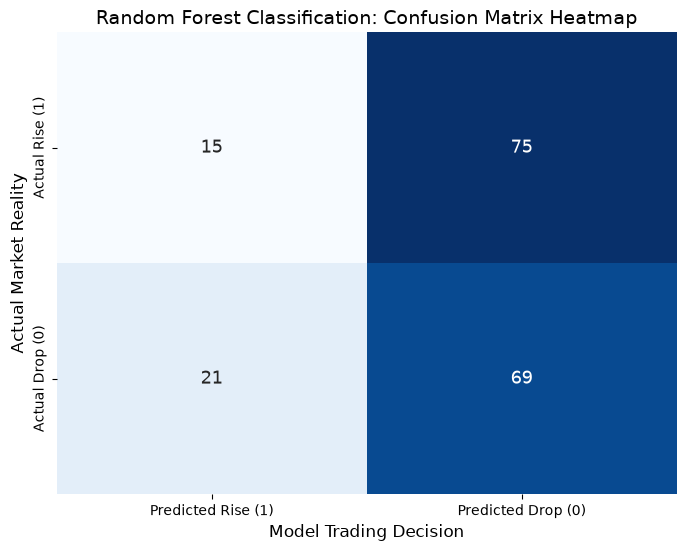

In [52]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Rise (1)", "Predicted Drop (0)"],
    yticklabels=["Actual Rise (1)", "Actual Drop (0)"],
    annot_kws={"size": 13},
    cbar=False
)

plt.title("Random Forest Classification: Confusion Matrix Heatmap", fontsize=14)
plt.ylabel("Actual Market Reality", fontsize=12)
plt.xlabel("Model Trading Decision", fontsize=12)
plt.show()

# 386

In [53]:
ticker = "0386.HK"
data = yf.download(ticker, start="2023-01-01", end="2026-09-30",auto_adjust=True, progress=False
                  ).droplevel(['Ticker'], axis=1).reset_index(drop=False).rename_axis(ticker)

In [54]:
data['Return'] = data.Close.pct_change()
data['Target'] = data['Return'].shift(-1)
data['Direction'] = (data['Target'] > 0).astype(int)
data["MA5"] = data["Close"].rolling(5).mean()
data["MA20"] = data["Close"].rolling(20).mean()
data["Volatility_5"] = data["Return"].rolling(5).std()
data = data.dropna(axis=0)
data.tail(3)

Price,Date,Close,High,Low,Open,Volume,Return,Target,Direction,MA5,MA20,Volatility_5
0386.HK,,,,,,,,,,,,
914,2026-09-24,4.485,4.505,4.405,4.415,117509056,0.008999,-0.013378,0,4.45354,4.579036,0.011235
915,2026-09-25,4.425,4.475,4.410,4.460,77682942,-0.013378,0.016949,1,4.46100,4.568496,0.013928
916,2026-09-28,4.500,4.530,4.440,4.440,116068405,0.016949,-0.021111,0,4.46400,4.560734,0.012089


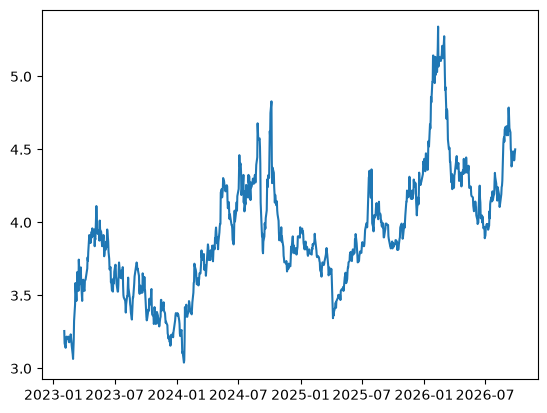

In [55]:
plt.plot(data.Date,data.Close)
plt.show()

## Regression

In [56]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0161
MAE     : 0.0124
R2 Score: -0.0055
MAPE    : 6.858e+11


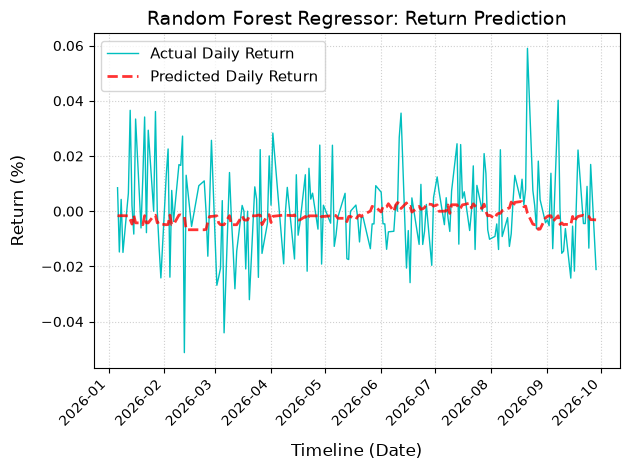

In [57]:
plt.plot(data['Date'][split_idx:], data['Target'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [58]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

result_fig = [[],[],[]]
rmse_list = [[],[],[]]
mae_list = [[],[],[]]
r2_score_list = [[],[],[]]


for n in [1,2,3]:
    for d in range(3, 11, 1):
        reg_model = RandomForestRegressor(n_estimators=n*100, max_depth=d, random_state=42, n_jobs=-1, min_samples_leaf=30)
        reg_model.fit(X_train_r, y_train_r)

        y_pred_r = reg_model.predict(X_test_r)
        result_fig[n-1].append(y_pred_r)
        rmse_reg = root_mean_squared_error(y_test_r, y_pred_r)
        mae_reg = mean_absolute_error(y_test_r, y_pred_r)
        r2_reg = r2_score(y_test_r, y_pred_r)
        rmse_list[n-1].append(rmse_reg)
        mae_list[n-1].append(mae_reg)
        r2_score_list[n-1].append(r2_reg)
        print(f"n_estimators: {n*100}, max_depth: {d}")
        print(f"RMSE    : {rmse_reg:.4f}")
        print(f"MAE     : {mae_reg:.4f}")
        print(f"R2 Score: {r2_reg:.4f}")
        print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

n_estimators: 100, max_depth: 3
RMSE    : 0.0161
MAE     : 0.0124
R2 Score: -0.0063
MAPE    : 6.928e+11
n_estimators: 100, max_depth: 4
RMSE    : 0.0161
MAE     : 0.0124
R2 Score: -0.0055
MAPE    : 6.858e+11
n_estimators: 100, max_depth: 5
RMSE    : 0.0161
MAE     : 0.0124
R2 Score: -0.0064
MAPE    : 6.612e+11
n_estimators: 100, max_depth: 6
RMSE    : 0.0161
MAE     : 0.0123
R2 Score: -0.0065
MAPE    : 6.639e+11
n_estimators: 100, max_depth: 7
RMSE    : 0.0161
MAE     : 0.0123
R2 Score: -0.0067
MAPE    : 6.621e+11
n_estimators: 100, max_depth: 8
RMSE    : 0.0161
MAE     : 0.0123
R2 Score: -0.0067
MAPE    : 6.652e+11
n_estimators: 100, max_depth: 9
RMSE    : 0.0161
MAE     : 0.0123
R2 Score: -0.0062
MAPE    : 6.651e+11
n_estimators: 100, max_depth: 10
RMSE    : 0.0161
MAE     : 0.0123
R2 Score: -0.0064
MAPE    : 6.641e+11
n_estimators: 200, max_depth: 3
RMSE    : 0.0161
MAE     : 0.0124
R2 Score: -0.0030
MAPE    : 6.36e+11
n_estimators: 200, max_depth: 4
RMSE    : 0.0161
MAE     : 0.012

In [59]:
r2_array = np.array(r2_score_list)
best_n, best_d = np.where(r2_array == r2_array.max())
best_n = (best_n+1)*100
best_d = best_d+3
print(f"Best n_estimators and max_depth: {best_n}, {best_d}")

Best n_estimators and max_depth: [200], [6]


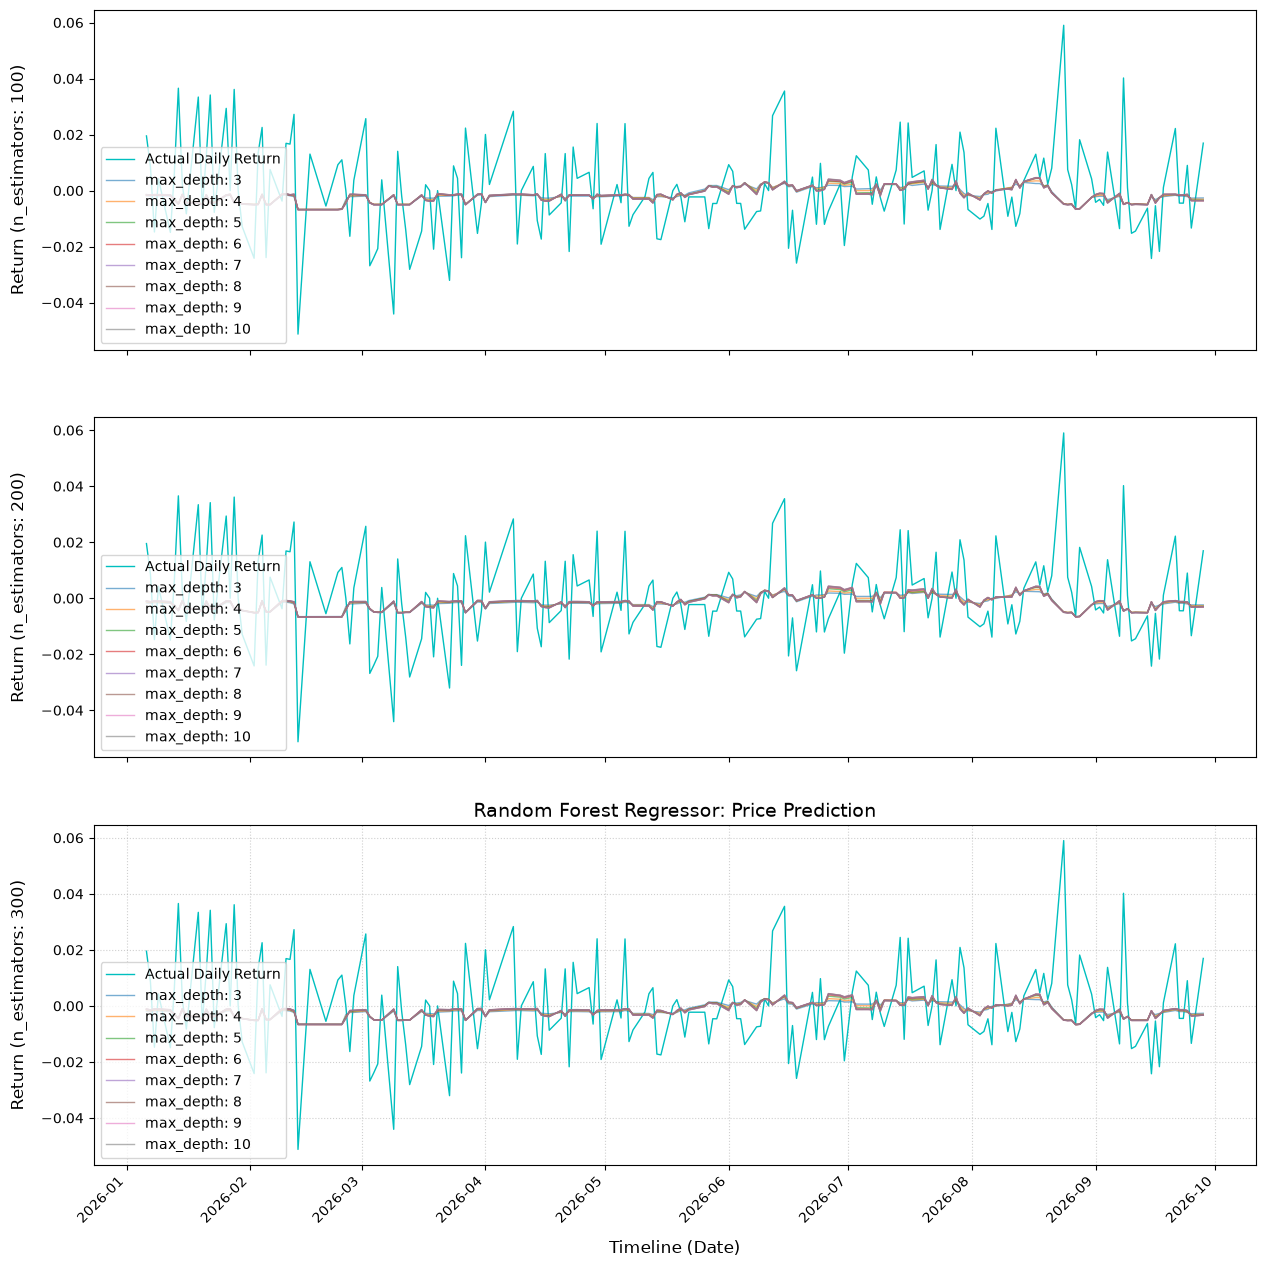

In [60]:
fig, axs = plt.subplots(3,1, figsize=(15,15), sharex=True)
for i in range(3):
    axs[i].plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
    for j in range(3,11,1):
        axs[i].plot(data['Date'][split_idx:], result_fig[i][j-3], label=f"max_depth: {j}", linewidth=1, alpha=0.6)
    axs[i].set_ylabel(f"Return (n_estimators: {(i+1)*100})", fontsize=12, labelpad=10)
    axs[i].legend()
    plt.grid(True, linestyle=":", alpha=0.6)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.show()

In [61]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0161
MAE     : 0.0123
R2 Score: -0.0015
MAPE    : 5.696e+11


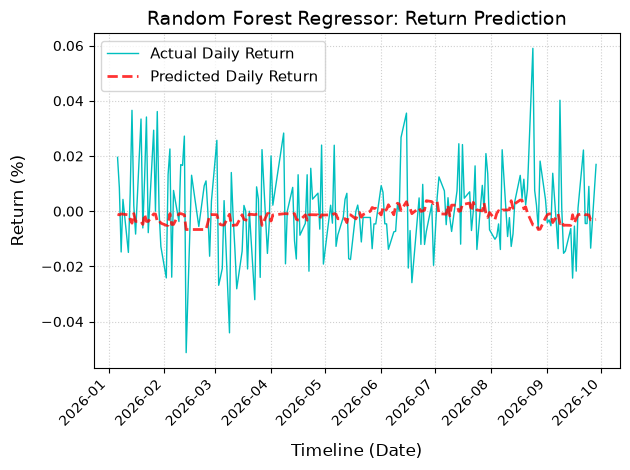

In [62]:
plt.plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [63]:
pred_data = pd.DataFrame(data['Date'][split_idx:].copy()) 
pred_data['Pre_Return'] = y_pred_r 
pred_data['Close'] = data['Close'].copy()
a = [data['Close'].iloc[pred_data.index[0]-data.index[0]]]
for i in range(len(pred_data['Pre_Return'])):
    a.append(a[i-1]*(1+pred_data['Pre_Return'].iloc[i-1]))
pred_data['Pre_Close'] = a[:-1]
pred_data.tail()

,Date,Pre_Return,Close,Pre_Close
0386.HK,,,,
912,2026-09-22,-0.001272,4.465,3.906222
913,2026-09-23,-0.001272,4.445,3.913821
914,2026-09-24,-0.001333,4.485,3.901252
915,2026-09-25,-0.003127,4.425,3.908841
916,2026-09-28,-0.003013,4.500,3.896052


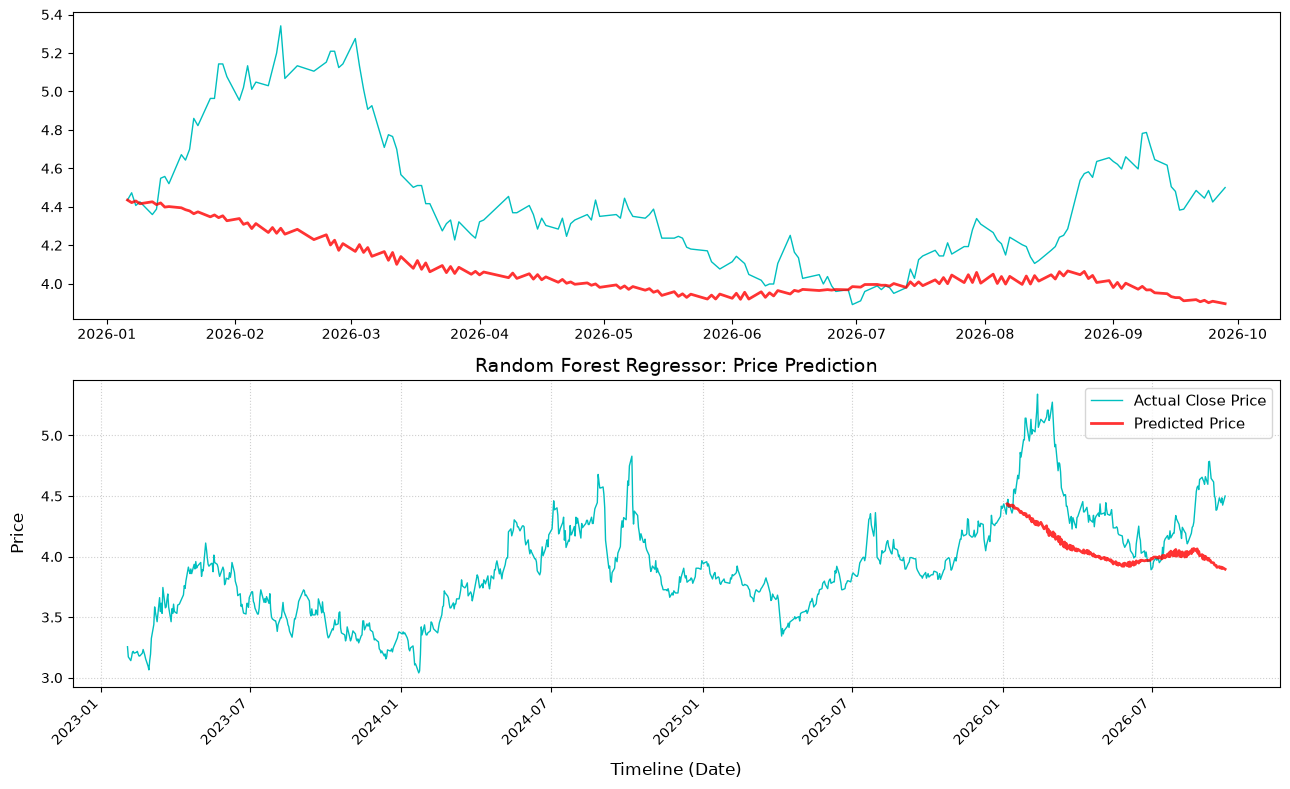

In [64]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(13,8))
ax1.plot(data['Date'][split_idx:], data['Close'][split_idx:], 'c-', label='Actual Close Price', linewidth=1)
ax1.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)
ax2.plot(data['Date'], data['Close'], 'c-', label='Actual Close Price', linewidth=1)
ax2.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Price", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [65]:
print(f"RMSE    : {root_mean_squared_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAE     : {mean_absolute_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"R2 Score: {r2_score(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4}")

RMSE    : 0.4562
MAE     : 0.3667
R2 Score: -0.7268
MAPE    : 0.07903


## Classification

In [66]:
y_cl = data["Direction"]
X_cl = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data) * 0.8)
X_train_c, X_test_c = X_cl.iloc[:split_idx], X_cl.iloc[split_idx:]
y_train_c, y_test_c = y_cl.iloc[:split_idx], y_cl.iloc[split_idx:]

reg_model = RandomForestClassifier(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1)
reg_model.fit(X_train_c, y_train_c)
y_pred_c = reg_model.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.56      0.93      0.70        98
           1       0.59      0.12      0.20        82

    accuracy                           0.56       180
   macro avg       0.57      0.53      0.45       180
weighted avg       0.57      0.56      0.47       180



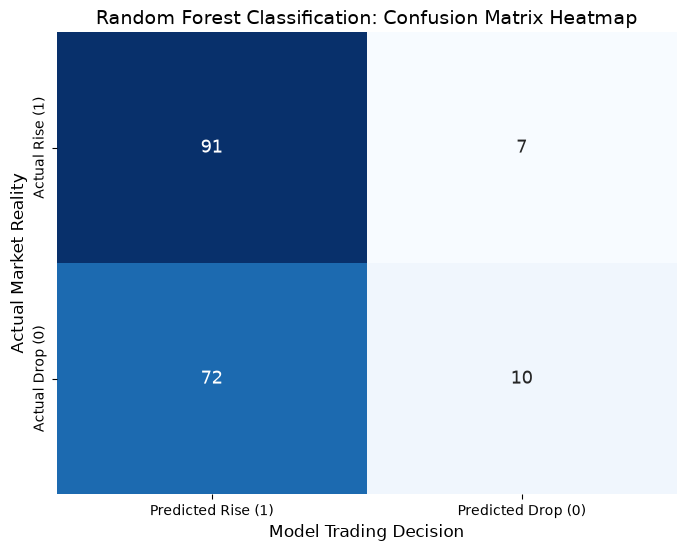

In [67]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Rise (1)", "Predicted Drop (0)"],
    yticklabels=["Actual Rise (1)", "Actual Drop (0)"],
    annot_kws={"size": 13},
    cbar=False
)

plt.title("Random Forest Classification: Confusion Matrix Heatmap", fontsize=14)
plt.ylabel("Actual Market Reality", fontsize=12)
plt.xlabel("Model Trading Decision", fontsize=12)
plt.show()

# 388

In [68]:
ticker = "0388.HK"
data = yf.download(ticker, start="2023-01-01", end="2026-09-30",auto_adjust=True, progress=False
                  ).droplevel(['Ticker'], axis=1).reset_index(drop=False).rename_axis(ticker)

In [69]:
data['Return'] = data.Close.pct_change()
data['Target'] = data['Return'].shift(-1)
data['Direction'] = (data['Target'] > 0).astype(int)
data["MA5"] = data["Close"].rolling(5).mean()
data["MA20"] = data["Close"].rolling(20).mean()
data["Volatility_5"] = data["Return"].rolling(5).std()
data = data.dropna(axis=0)
data.tail(3)

Price,Date,Close,High,Low,Open,Volume,Return,Target,Direction,MA5,MA20,Volatility_5
0388.HK,,,,,,,,,,,,
914,2026-09-24,393.399994,393.799988,390.200012,390.799988,1630895,-0.006064,-0.012710,0,393.159998,399.688048,0.009267
915,2026-09-25,388.399994,393.000000,386.200012,393.000000,3312729,-0.012710,0.000515,1,393.239996,398.278499,0.011547
916,2026-09-28,388.600006,392.399994,388.200012,388.399994,2655471,0.000515,-0.004632,0,392.719995,396.819998,0.010697


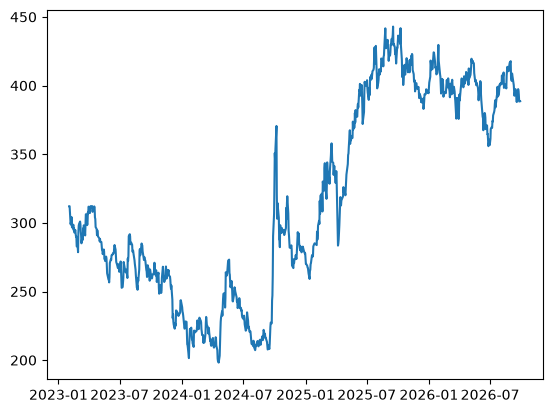

In [70]:
plt.plot(data.Date,data.Close)
plt.show()

## Regression

In [71]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0126
MAE     : 0.0100
R2 Score: 0.0090
MAPE    : 6.536e+10


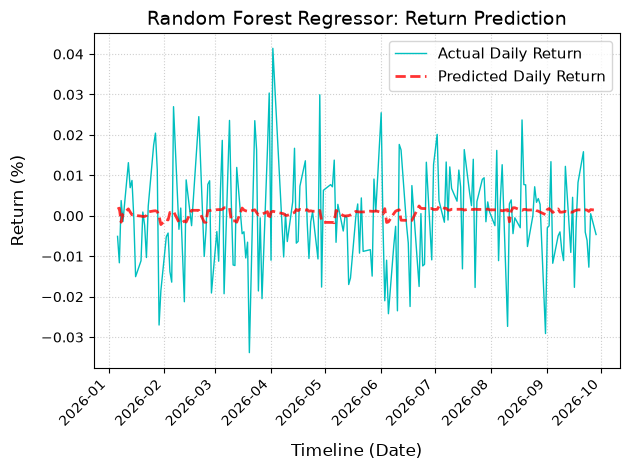

In [72]:
plt.plot(data['Date'][split_idx:], data['Target'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [73]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

result_fig = [[],[],[]]
rmse_list = [[],[],[]]
mae_list = [[],[],[]]
r2_score_list = [[],[],[]]


for n in [1,2,3]:
    for d in range(3, 11, 1):
        reg_model = RandomForestRegressor(n_estimators=n*100, max_depth=d, random_state=42, n_jobs=-1, min_samples_leaf=30)
        reg_model.fit(X_train_r, y_train_r)

        y_pred_r = reg_model.predict(X_test_r)
        result_fig[n-1].append(y_pred_r)
        rmse_reg = root_mean_squared_error(y_test_r, y_pred_r)
        mae_reg = mean_absolute_error(y_test_r, y_pred_r)
        r2_reg = r2_score(y_test_r, y_pred_r)
        rmse_list[n-1].append(rmse_reg)
        mae_list[n-1].append(mae_reg)
        r2_score_list[n-1].append(r2_reg)
        print(f"n_estimators: {n*100}, max_depth: {d}")
        print(f"RMSE    : {rmse_reg:.4f}")
        print(f"MAE     : {mae_reg:.4f}")
        print(f"R2 Score: {r2_reg:.4f}")
        print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

n_estimators: 100, max_depth: 3
RMSE    : 0.0127
MAE     : 0.0100
R2 Score: 0.0068
MAPE    : 3.35e+10
n_estimators: 100, max_depth: 4
RMSE    : 0.0126
MAE     : 0.0100
R2 Score: 0.0090
MAPE    : 6.536e+10
n_estimators: 100, max_depth: 5
RMSE    : 0.0127
MAE     : 0.0101
R2 Score: 0.0031
MAPE    : 1.023e+11
n_estimators: 100, max_depth: 6
RMSE    : 0.0127
MAE     : 0.0101
R2 Score: -0.0055
MAPE    : 1.377e+11
n_estimators: 100, max_depth: 7
RMSE    : 0.0128
MAE     : 0.0101
R2 Score: -0.0112
MAPE    : 1.483e+11
n_estimators: 100, max_depth: 8
RMSE    : 0.0128
MAE     : 0.0101
R2 Score: -0.0151
MAPE    : 1.506e+11
n_estimators: 100, max_depth: 9
RMSE    : 0.0128
MAE     : 0.0102
R2 Score: -0.0173
MAPE    : 1.531e+11
n_estimators: 100, max_depth: 10
RMSE    : 0.0128
MAE     : 0.0102
R2 Score: -0.0178
MAPE    : 1.545e+11
n_estimators: 200, max_depth: 3
RMSE    : 0.0127
MAE     : 0.0100
R2 Score: 0.0055
MAPE    : 2.83e+10
n_estimators: 200, max_depth: 4
RMSE    : 0.0126
MAE     : 0.0100
R2 

In [74]:
r2_array = np.array(r2_score_list)
best_n, best_d = np.where(r2_array == r2_array.max())
best_n = (best_n+1)*100
best_d = best_d+3
print(f"Best n_estimators and max_depth: {best_n}, {best_d}")

Best n_estimators and max_depth: [300], [5]


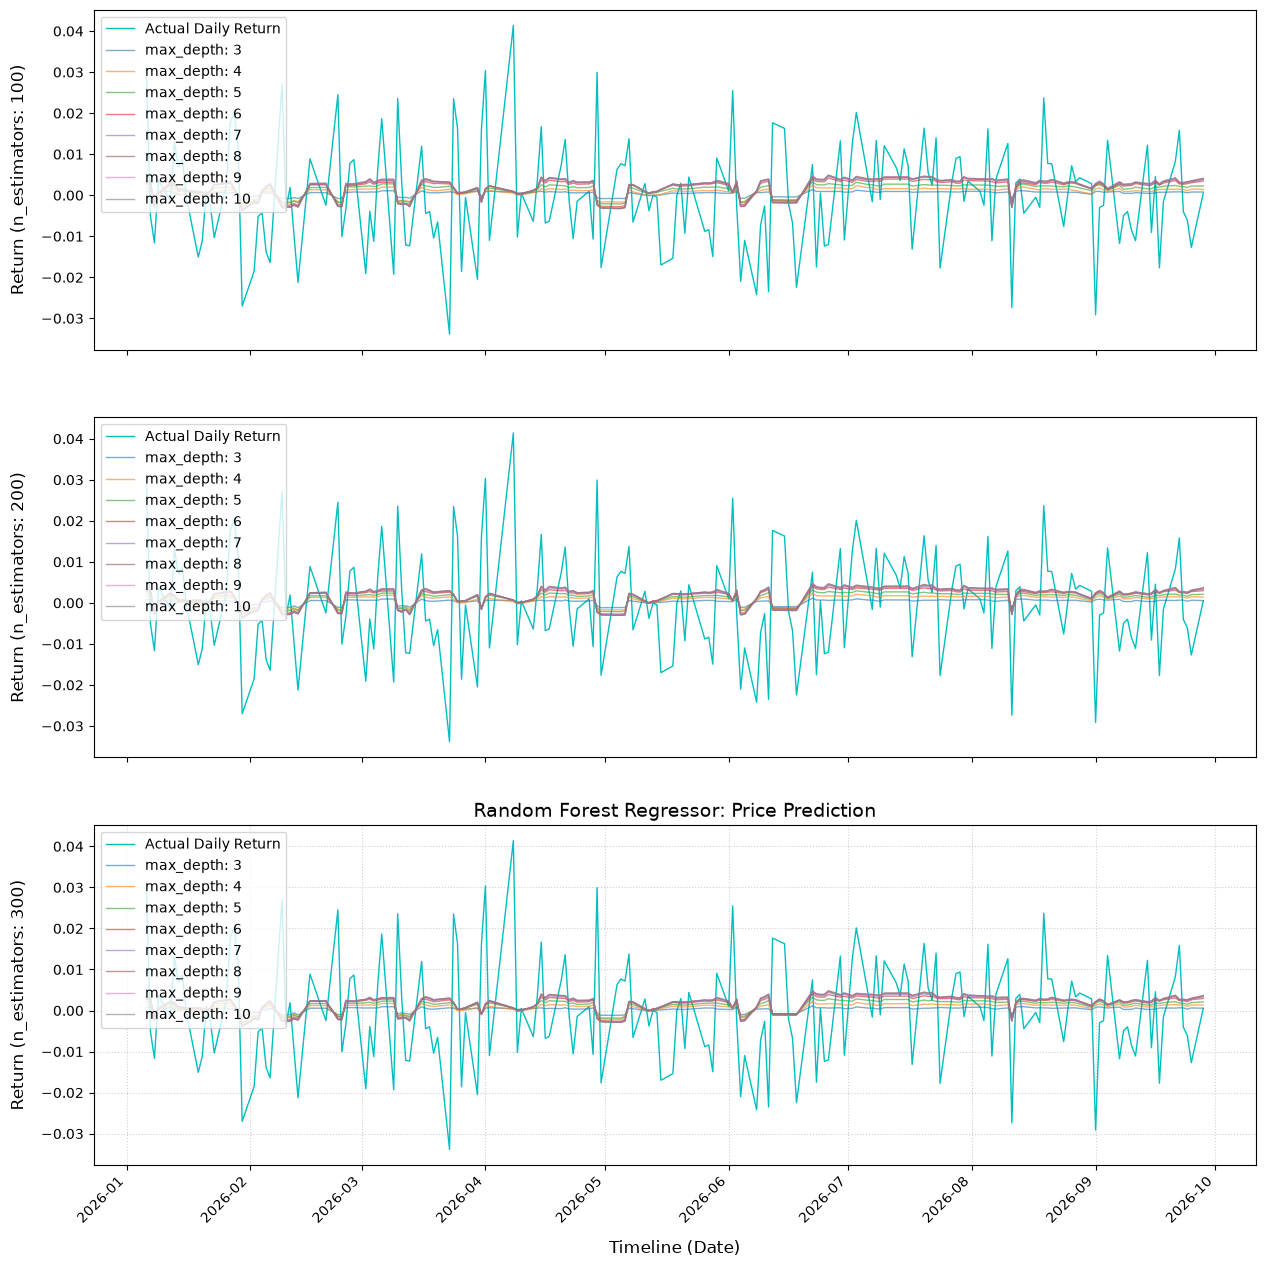

In [75]:
fig, axs = plt.subplots(3,1, figsize=(15,15), sharex=True)
for i in range(3):
    axs[i].plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
    for j in range(3,11,1):
        axs[i].plot(data['Date'][split_idx:], result_fig[i][j-3], label=f"max_depth: {j}", linewidth=1, alpha=0.6)
    axs[i].set_ylabel(f"Return (n_estimators: {(i+1)*100})", fontsize=12, labelpad=10)
    axs[i].legend()
    plt.grid(True, linestyle=":", alpha=0.6)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.show()

In [76]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0126
MAE     : 0.0100
R2 Score: 0.0092
MAPE    : 8.281e+10


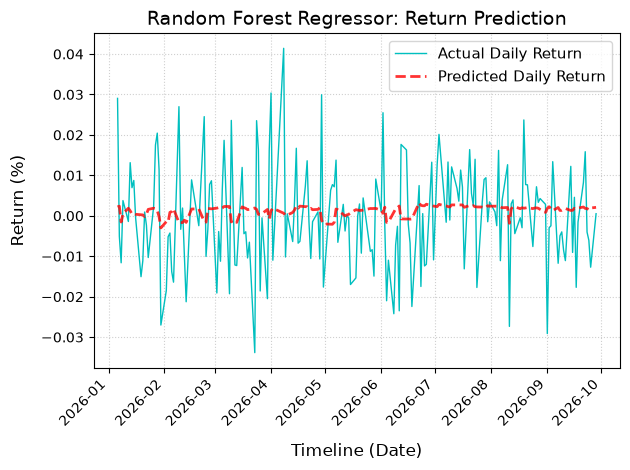

In [77]:
plt.plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [78]:
pred_data = pd.DataFrame(data['Date'][split_idx:].copy()) 
pred_data['Pre_Return'] = y_pred_r 
pred_data['Close'] = data['Close'].copy()
a = [data['Close'].iloc[pred_data.index[0]-data.index[0]]]
for i in range(len(pred_data['Pre_Return'])):
    a.append(a[i-1]*(1+pred_data['Pre_Return'].iloc[i-1]))
pred_data['Pre_Close'] = a[:-1]
pred_data.tail()

,Date,Pre_Return,Close,Pre_Close
0388.HK,,,,
912,2026-09-22,0.001818,397.399994,463.155964
913,2026-09-23,0.001790,395.799988,464.985006
914,2026-09-24,0.001509,393.399994,463.997919
915,2026-09-25,0.001930,388.399994,465.817434
916,2026-09-28,0.002084,388.600006,464.698147


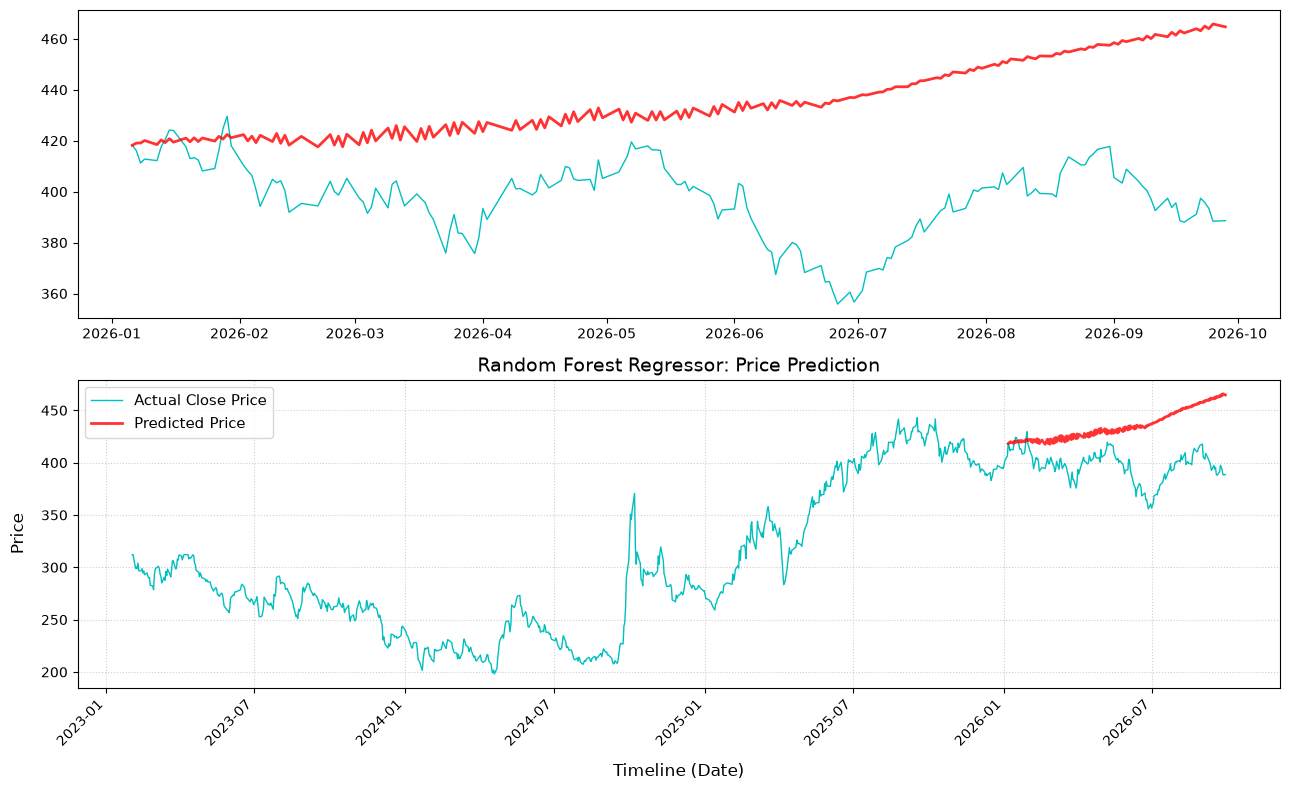

In [79]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(13,8))
ax1.plot(data['Date'][split_idx:], data['Close'][split_idx:], 'c-', label='Actual Close Price', linewidth=1)
ax1.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)
ax2.plot(data['Date'], data['Close'], 'c-', label='Actual Close Price', linewidth=1)
ax2.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Price", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [80]:
print(f"RMSE    : {root_mean_squared_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAE     : {mean_absolute_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"R2 Score: {r2_score(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4}")

RMSE    : 43.4594
MAE     : 37.9206
R2 Score: -7.9258
MAPE    : 0.09696


## Classification

In [81]:
y_cl = data["Direction"]
X_cl = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data) * 0.8)
X_train_c, X_test_c = X_cl.iloc[:split_idx], X_cl.iloc[split_idx:]
y_train_c, y_test_c = y_cl.iloc[:split_idx], y_cl.iloc[split_idx:]

reg_model = RandomForestClassifier(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1)
reg_model.fit(X_train_c, y_train_c)
y_pred_c = reg_model.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.72      0.13      0.23        97
           1       0.48      0.94      0.64        83

    accuracy                           0.51       180
   macro avg       0.60      0.54      0.43       180
weighted avg       0.61      0.51      0.42       180



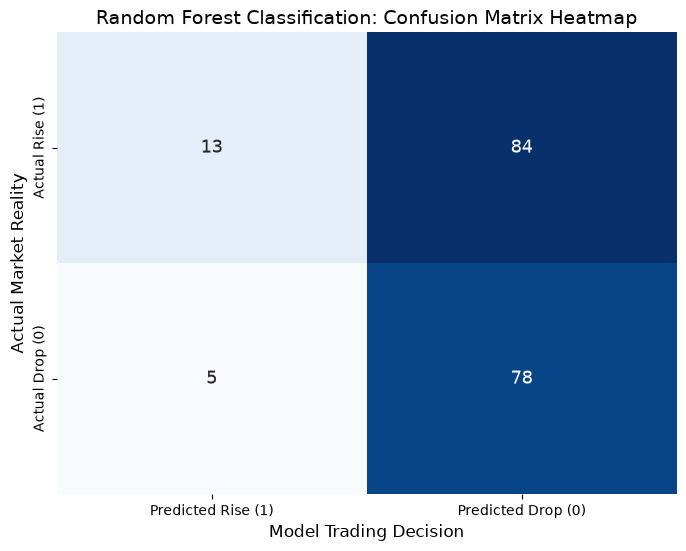

In [82]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Rise (1)", "Predicted Drop (0)"],
    yticklabels=["Actual Rise (1)", "Actual Drop (0)"],
    annot_kws={"size": 13},
    cbar=False
)

plt.title("Random Forest Classification: Confusion Matrix Heatmap", fontsize=14)
plt.ylabel("Actual Market Reality", fontsize=12)
plt.xlabel("Model Trading Decision", fontsize=12)
plt.show()

# 0005

In [83]:
ticker = "0005.HK"
data = yf.download(ticker, start="2023-01-01", end="2026-09-30",auto_adjust=True, progress=False
                  ).droplevel(['Ticker'], axis=1).reset_index(drop=False).rename_axis(ticker)

In [84]:
data['Return'] = data.Close.pct_change()
data['Target'] = data['Return'].shift(-1)
data['Direction'] = (data['Target'] > 0).astype(int)
data["MA5"] = data["Close"].rolling(5).mean()
data["MA20"] = data["Close"].rolling(20).mean()
data["Volatility_5"] = data["Return"].rolling(5).std()
data = data.dropna(axis=0)
data.tail(3)

Price,Date,Close,High,Low,Open,Volume,Return,Target,Direction,MA5,MA20,Volatility_5
0005.HK,,,,,,,,,,,,
914,2026-09-24,156.899994,158.399994,156.300003,157.500000,10699228,-0.016301,0.004462,1,159.760001,162.315000,0.011349
915,2026-09-25,157.600006,158.000000,155.699997,156.899994,6560612,0.004462,0.008249,1,158.960001,162.125001,0.009353
916,2026-09-28,158.899994,160.800003,157.899994,157.899994,12819424,0.008249,0.000629,1,158.439999,162.020000,0.011067


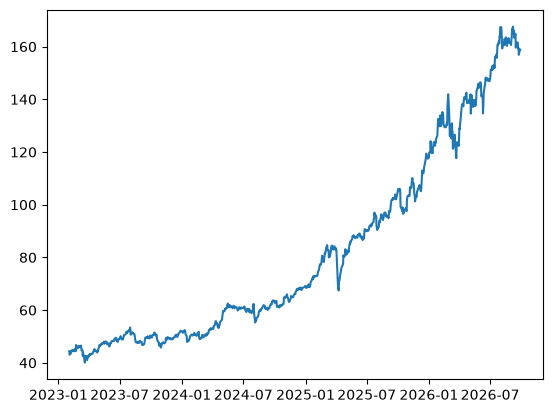

In [85]:
plt.plot(data.Date,data.Close)
plt.show()

## Regression

In [86]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0106
MAPE    : 1.775e+11


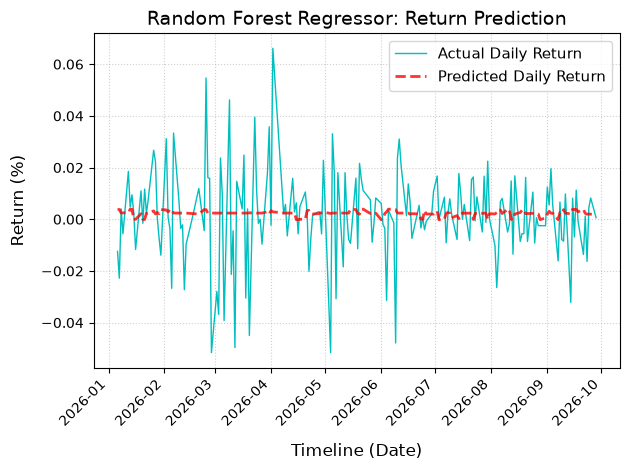

In [87]:
plt.plot(data['Date'][split_idx:], data['Target'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [88]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

result_fig = [[],[],[]]
rmse_list = [[],[],[]]
mae_list = [[],[],[]]
r2_score_list = [[],[],[]]


for n in [1,2,3]:
    for d in range(3, 11, 1):
        reg_model = RandomForestRegressor(n_estimators=n*100, max_depth=d, random_state=42, n_jobs=-1, min_samples_leaf=30)
        reg_model.fit(X_train_r, y_train_r)

        y_pred_r = reg_model.predict(X_test_r)
        result_fig[n-1].append(y_pred_r)
        rmse_reg = root_mean_squared_error(y_test_r, y_pred_r)
        mae_reg = mean_absolute_error(y_test_r, y_pred_r)
        r2_reg = r2_score(y_test_r, y_pred_r)
        rmse_list[n-1].append(rmse_reg)
        mae_list[n-1].append(mae_reg)
        r2_score_list[n-1].append(r2_reg)
        print(f"n_estimators: {n*100}, max_depth: {d}")
        print(f"RMSE    : {rmse_reg:.4f}")
        print(f"MAE     : {mae_reg:.4f}")
        print(f"R2 Score: {r2_reg:.4f}")
        print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

n_estimators: 100, max_depth: 3
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0083
MAPE    : 1.738e+11
n_estimators: 100, max_depth: 4
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0106
MAPE    : 1.775e+11
n_estimators: 100, max_depth: 5
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0124
MAPE    : 1.875e+11
n_estimators: 100, max_depth: 6
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0124
MAPE    : 1.875e+11
n_estimators: 100, max_depth: 7
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0124
MAPE    : 1.889e+11
n_estimators: 100, max_depth: 8
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0124
MAPE    : 1.897e+11
n_estimators: 100, max_depth: 9
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0124
MAPE    : 1.897e+11
n_estimators: 100, max_depth: 10
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0124
MAPE    : 1.897e+11
n_estimators: 200, max_depth: 3
RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0091
MAPE    : 1.757e+11
n_estimators: 200, max_depth: 4
RMSE    : 0.0178
MAE     : 0.01

In [89]:
r2_array = np.array(r2_score_list)
best_n, best_d = np.where(r2_array == r2_array.max())
best_n = (best_n+1)*100
best_d = best_d+3
print(f"Best n_estimators and max_depth: {best_n}, {best_d}")

Best n_estimators and max_depth: [300], [3]


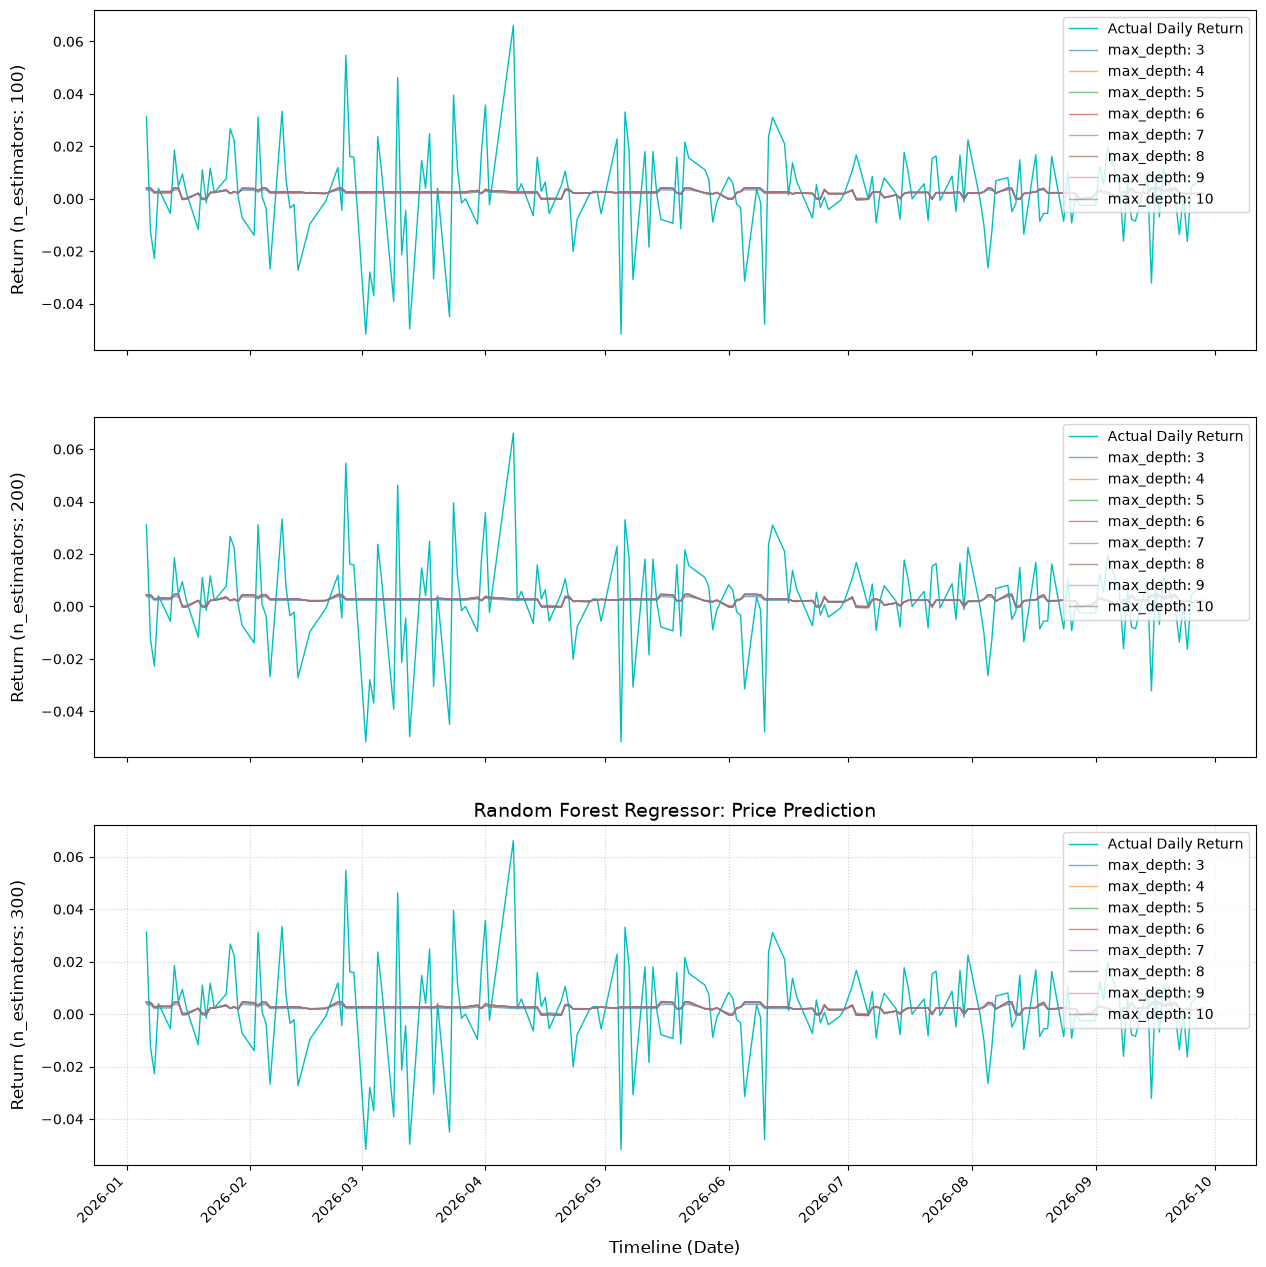

In [90]:
fig, axs = plt.subplots(3,1, figsize=(15,15), sharex=True)
for i in range(3):
    axs[i].plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
    for j in range(3,11,1):
        axs[i].plot(data['Date'][split_idx:], result_fig[i][j-3], label=f"max_depth: {j}", linewidth=1, alpha=0.6)
    axs[i].set_ylabel(f"Return (n_estimators: {(i+1)*100})", fontsize=12, labelpad=10)
    axs[i].legend()
    plt.grid(True, linestyle=":", alpha=0.6)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.show()

In [91]:
y_reg = data["Target"]
X_reg = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data)*0.8)
X_train_r, X_test_r = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_train_r, y_test_r = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

reg_model = RandomForestRegressor(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1, min_samples_leaf=30)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
print(f"RMSE    : {root_mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"MAE     : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(y_test_r, y_pred_r):.4}")

RMSE    : 0.0178
MAE     : 0.0127
R2 Score: -0.0082
MAPE    : 1.655e+11


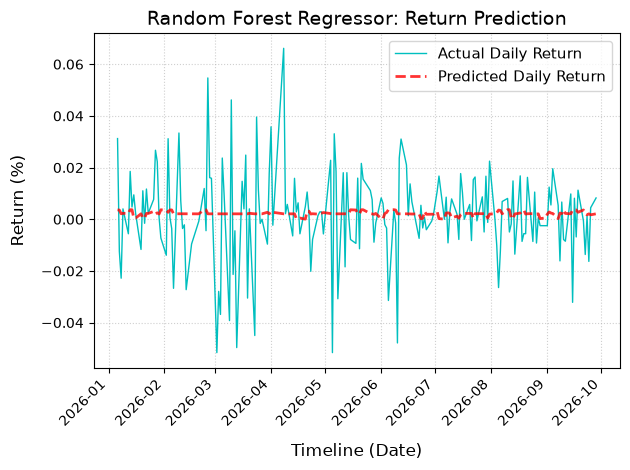

In [92]:
plt.plot(data['Date'][split_idx:], data['Return'][split_idx:], 'c-', label='Actual Daily Return', linewidth=1)
plt.plot(data['Date'][split_idx:], y_pred_r, 'r--', label="Predicted Daily Return", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Return Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Return (%)", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [93]:
pred_data = pd.DataFrame(data['Date'][split_idx:].copy()) 
pred_data['Pre_Return'] = y_pred_r 
pred_data['Close'] = data['Close'].copy()
a = [data['Close'].iloc[pred_data.index[0]-data.index[0]]]
for i in range(len(pred_data['Pre_Return'])):
    a.append(a[i-1]*(1+pred_data['Pre_Return'].iloc[i-1]))
pred_data['Pre_Close'] = a[:-1]
pred_data.tail()

,Date,Pre_Return,Close,Pre_Close
0005.HK,,,,
912,2026-09-22,0.002184,159.300003,149.978378
913,2026-09-23,0.001725,159.500000,150.855690
914,2026-09-24,0.002099,156.899994,150.305982
915,2026-09-25,0.001725,157.600006,151.115969
916,2026-09-28,0.002121,158.899994,150.621407


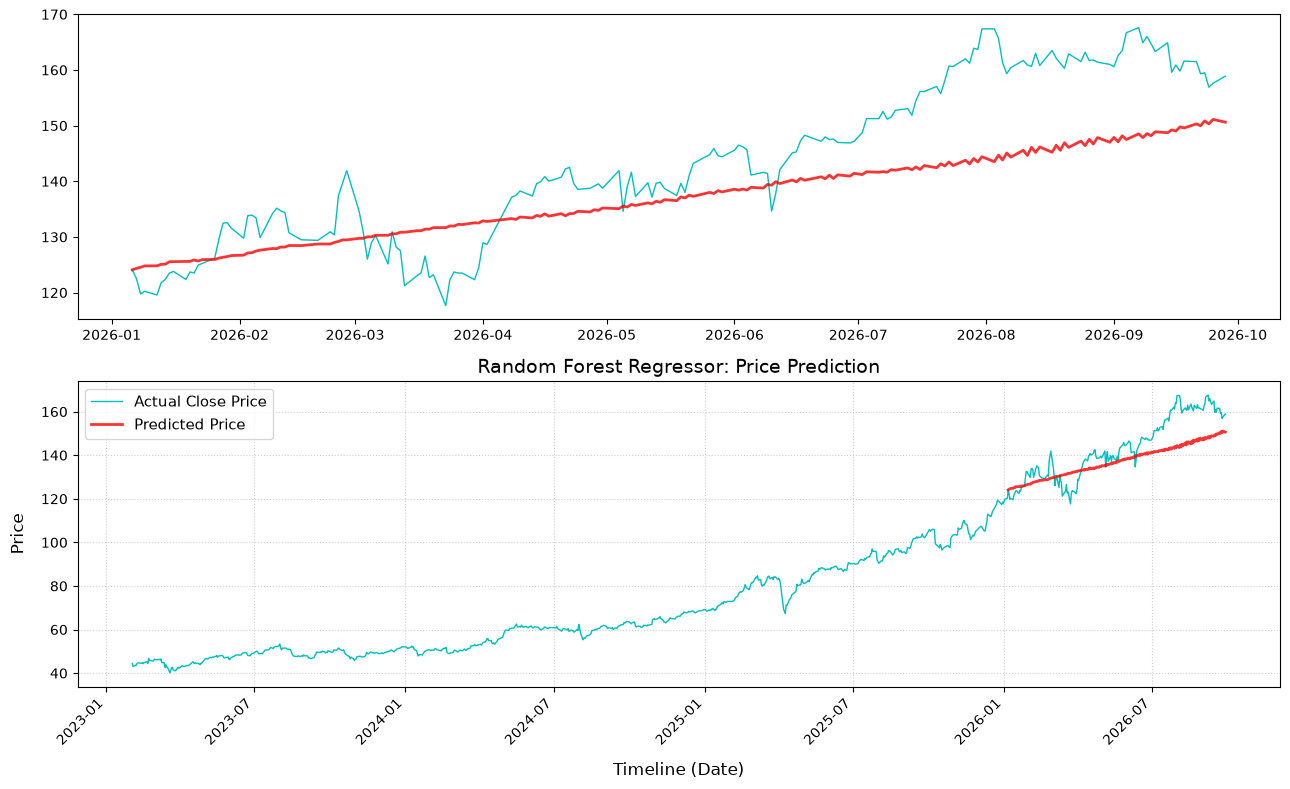

In [94]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(13,8))
ax1.plot(data['Date'][split_idx:], data['Close'][split_idx:], 'c-', label='Actual Close Price', linewidth=1)
ax1.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)
ax2.plot(data['Date'], data['Close'], 'c-', label='Actual Close Price', linewidth=1)
ax2.plot(data['Date'][split_idx:], pred_data['Pre_Close'], 'r-', label="Predicted Price", linewidth=2, alpha=0.8)

plt.title("Random Forest Regressor: Price Prediction", fontsize=14)
plt.xlabel("Timeline (Date)", fontsize=12, labelpad=10)
plt.ylabel("Price", fontsize=12, labelpad=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [95]:
print(f"RMSE    : {root_mean_squared_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAE     : {mean_absolute_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"R2 Score: {r2_score(data['Close'][split_idx:], pred_data['Pre_Close']):.4f}")
print(f"MAPE    : {mean_absolute_percentage_error(data['Close'][split_idx:], pred_data['Pre_Close']):.4}")

RMSE    : 9.8790
MAE     : 8.1876
R2 Score: 0.5162
MAPE    : 0.05476


## Classification

In [96]:
y_cl = data["Direction"]
X_cl = data[["MA5", "MA20", "Volatility_5"]]

split_idx = int(len(data) * 0.8)
X_train_c, X_test_c = X_cl.iloc[:split_idx], X_cl.iloc[split_idx:]
y_train_c, y_test_c = y_cl.iloc[:split_idx], y_cl.iloc[split_idx:]

reg_model = RandomForestClassifier(n_estimators=best_n[0], max_depth=best_d[0], random_state=42, n_jobs=-1)
reg_model.fit(X_train_c, y_train_c)
y_pred_c = reg_model.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        81
           1       0.55      1.00      0.71        99

    accuracy                           0.55       180
   macro avg       0.28      0.50      0.35       180
weighted avg       0.30      0.55      0.39       180



C:\Users\ryanp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ryanp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ryanp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

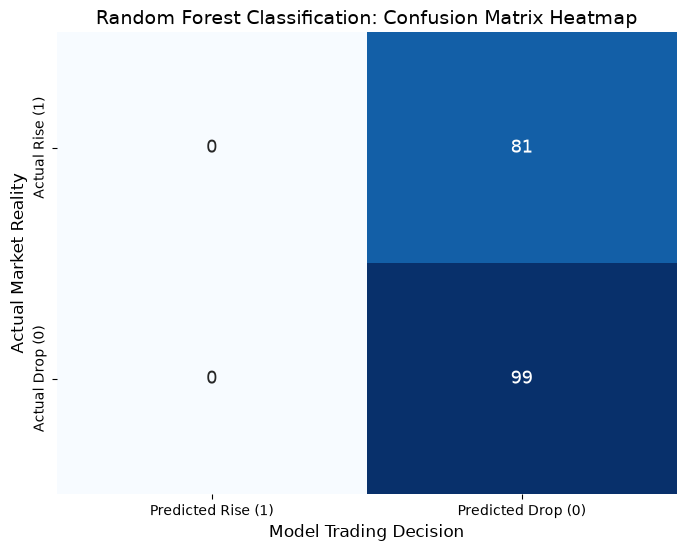

In [97]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted Rise (1)", "Predicted Drop (0)"],
    yticklabels=["Actual Rise (1)", "Actual Drop (0)"],
    annot_kws={"size": 13},
    cbar=False
)

plt.title("Random Forest Classification: Confusion Matrix Heatmap", fontsize=14)
plt.ylabel("Actual Market Reality", fontsize=12)
plt.xlabel("Model Trading Decision", fontsize=12)
plt.show()